In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('/content/placement.csv')

In [4]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [8]:
df.shape

(100, 4)

In [9]:
df.info(

)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [10]:
df=df.iloc[:,1:]

In [11]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [12]:
import matplotlib.pyplot as plt


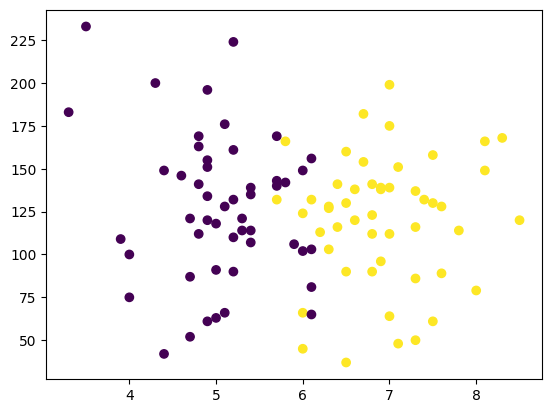

In [14]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [15]:
X=df.iloc[:,0:2]
Y=df.iloc[:,-1]

In [16]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [17]:
Y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [19]:
Y.shape

(100,)

In [21]:
from sklearn.model_selection import train_test_split
X_train ,X_test ,Y_train , Y_test = train_test_split(X,Y,test_size=0.1)

In [22]:
X_train

,cgpa,iq
21,7.1,151.0
79,6.5,90.0
62,6.0,102.0
87,5.7,132.0
14,6.1,103.0
...,...,...
20,6.6,120.0
30,7.6,128.0
70,6.3,127.0
28,5.2,90.0


In [23]:
Y_train

,placement
21,1
79,1
62,0
87,1
14,0
...,...
20,1
30,1
70,1
28,0


In [24]:
X_test

,cgpa,iq
97,6.7,182.0
26,7.0,199.0
48,6.6,138.0
49,5.4,135.0
6,5.7,143.0
1,5.9,106.0
12,5.4,139.0
78,6.1,81.0
85,5.8,166.0
53,8.3,168.0


In [25]:
Y_test

,placement
97,1
26,1
48,1
49,0
6,0
1,0
12,0
78,0
85,1
53,1


In [26]:
from sklearn.preprocessing import StandardScaler

In [27]:
scaler = StandardScaler()

In [28]:
X_train = scaler.fit_transform(X_train)

In [29]:
X_train

array([[ 0.98379918,  0.75360547],
       [ 0.46701751, -0.78499402],
       [ 0.03636612, -0.48231871],
       [-0.22202472,  0.27436956],
       [ 0.1224964 , -0.45709577],
       [ 1.32832029,  0.93016606],
       [-0.13589444,  0.52659898],
       [ 0.29475695,  0.17347779],
       [-0.91106694,  0.32481545],
       [-0.82493666, -0.75977107],
       [-0.65267611,  2.59488025],
       [ 0.63927806,  0.82927429],
       [-1.0833275 , -1.74346582],
       [ 0.72540834, -0.78499402],
       [ 0.03636612,  0.07258602],
       [ 1.15605973, -1.79391171],
       [ 0.1224964 ,  0.27436956],
       [-0.99719722,  1.20761843],
       [-1.34171833, -1.99569525],
       [ 1.75897168, -1.06244638],
       [ 0.72540834,  0.04736308],
       [ 1.32832029,  0.22392368],
       [-0.99719722,  1.05628077],
       [-0.91106694,  1.88863787],
       [-0.65267611,  1.00583489],
       [ 1.15605973,  0.40048427],
       [-0.22202472,  0.4761531 ],
       [-1.68623944, -1.16333815],
       [-1.0833275 ,

In [30]:
X_test=scaler.transform(X_test)

In [31]:
X_test

array([[ 0.63927806,  1.53551668],
       [ 0.8976689 ,  1.9643067 ],
       [ 0.55314779,  0.42570722],
       [-0.48041555,  0.35003839],
       [-0.22202472,  0.55182193],
       [-0.04976416, -0.38142694],
       [-0.48041555,  0.45093016],
       [ 0.1224964 , -1.0120005 ],
       [-0.13589444,  1.1319496 ],
       [ 2.01736251,  1.18239548]])

In [32]:
from sklearn.linear_model import LogisticRegression

In [33]:
clf=LogisticRegression()

In [34]:
clf.fit(X_train,Y_train)

LogisticRegression()

In [37]:
Y_pred = clf.predict(X_test)

In [36]:
Y_test

,placement
97,1
26,1
48,1
49,0
6,0
1,0
12,0
78,0
85,1
53,1


In [38]:
from sklearn.metrics import accuracy_score


In [39]:
accuracy_score(Y_test,Y_pred)

0.8

In [40]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

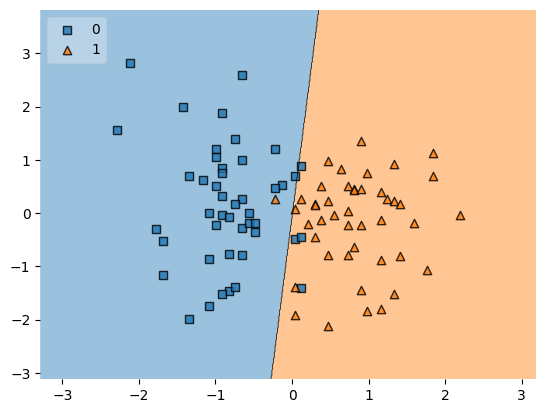

In [47]:
plot_decision_regions(X_train,Y_train.values,clf=clf,legend=2)

In [48]:
import pickle

In [50]:
pickle.dump(clf,open('model.pkl','wb'))